# Practica 09 — Pronostico de Riesgo de Infarto en Xicotepec de Juarez
**Equipo:** Ana Daniela López Neri, Tania Ibarra Salgado, Brandon León Cabrera — UTXicotepec
**Curso:** ECBD

Analisis predictivo multiclase del riesgo de infarto en los proximos 6 meses para los
pacientes simulados de Xicotepec de Juarez, Puebla, con fines academicos.
**Los resultados NO constituyen un diagnostico medico real.**

## 1. Librerias

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
np.random.seed(42)
from sklearn.cluster import KMeans

## 2. Carga del dataset grupal

In [74]:
df = pd.read_csv("../data/processed/dataset_grupal_referencia.csv")
print(df.shape)
df.head()

(15000, 19)


,id_paciente,edad,sexo,peso_kg,estatura_m,imc,presion_sistolica,presion_diastolica,glucosa_mg_dl,colesterol_mg_dl,tabaquismo,diabetes,actividad_fisica,antecedentes_familiares,municipio,latitud,longitud,riesgo_cardiovascular,autor_dataset
0,GRP-000001,62,M,86.2,1.56,34.8,176,94,169,223.0,no,si,alta,no,Zacatlan,19.899875,-98.019283,alto,Daniela
1,GRP-000002,35,F,94.0,1.46,24.9,102,66,71,121.0,no,no,alta,no,Venustiano Carranza,19.947391,-97.855138,bajo,Daniela
2,GRP-000003,39,F,77.7,1.52,24.1,120,88,136,181.0,no,no,alta,no,Teziutlan,19.812948,-97.413165,medio,Daniela
3,GRP-000004,38,M,60.2,1.67,26.9,141,84,127,217.0,no,no,moderada,si,Puebla,18.953904,-98.156676,medio,Daniela
4,GRP-000005,22,F,51.4,1.63,24.0,106,72,71,164.0,no,no,moderada,no,Acatlan,18.175512,-98.431035,bajo,Daniela


## 3. Filtrado de pacientes de Xicotepec de Juarez

In [75]:
df_xico = df[df['municipio'] == 'Xicotepec de Juarez'].copy().reset_index(drop=True)
print("Pacientes en Xicotepec de Juarez:", len(df_xico))

Pacientes en Xicotepec de Juarez: 469


## 4. Validacion del volumen de registros filtrados

In [76]:
n_min_recomendado = 100
n_xico = len(df_xico)
print(f"Registros filtrados para Xicotepec de Juarez: {n_xico}")
if n_xico >= n_min_recomendado:
    print(f"Volumen suficiente para un analisis supervisado (>= {n_min_recomendado} registros).")
else:
    print(f"ADVERTENCIA: volumen insuficiente (< {n_min_recomendado} registros). "
          f"Los resultados del modelo podrian no ser confiables con esta muestra.")

Registros filtrados para Xicotepec de Juarez: 469
Volumen suficiente para un analisis supervisado (>= 100 registros).


## 5. Revision de columnas disponibles

In [77]:
cols_clinicas = ['edad','presion_sistolica','presion_diastolica','glucosa_mg_dl',
                  'colesterol_mg_dl','imc','tabaquismo','diabetes','actividad_fisica',
                  'antecedentes_familiares']
cols_demo = ['sexo','edad']
cols_geo = ['latitud','longitud']
print("Clinicas:", cols_clinicas)
print("Geograficas:", cols_geo)

Clinicas: ['edad', 'presion_sistolica', 'presion_diastolica', 'glucosa_mg_dl', 'colesterol_mg_dl', 'imc', 'tabaquismo', 'diabetes', 'actividad_fisica', 'antecedentes_familiares']
Geograficas: ['latitud', 'longitud']


## 6. Revision detallada de variables demograficas y geograficas

In [78]:
# Variables demograficas: distribucion por sexo y estadisticas de edad
print("Distribucion por sexo:")
print(df_xico['sexo'].value_counts())
print()
print("Estadisticas descriptivas de la edad:")
print(df_xico['edad'].describe())

# Variables geograficas: validar que existan coordenadas completas y dentro de un rango razonable
print()
print("Nulos en columnas geograficas (latitud/longitud):", df_xico[cols_geo].isnull().sum().sum())
print(f"Rango de latitud:  {df_xico['latitud'].min():.4f} a {df_xico['latitud'].max():.4f}")
print(f"Rango de longitud: {df_xico['longitud'].min():.4f} a {df_xico['longitud'].max():.4f}")

Distribucion por sexo:
sexo
F    257
M    212
Name: count, dtype: int64

Estadisticas descriptivas de la edad:
count    469.000000
mean      45.801706
std       16.741790
min       18.000000
25%       34.000000
50%       43.000000
75%       55.000000
max       90.000000
Name: edad, dtype: float64

Nulos en columnas geograficas (latitud/longitud): 0
Rango de latitud:  20.1457 a 20.3960
Rango de longitud: -98.0711 a -97.8405


## 7. Analisis exploratorio inicial

Estadisticas descriptivas generales de las variables clinicas y demograficas de
los pacientes de Xicotepec de Juarez, antes de definir la variable objetivo y de
seleccionar las variables predictoras.

In [79]:
df_xico[cols_clinicas + ['sexo']].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
edad,469.0,NaN,NaN,NaN,45.801706,16.74179,18.0,34.0,43.0,55.0,90.0
presion_sistolica,469.0,NaN,NaN,NaN,127.8742,21.664082,95.0,111.0,124.0,141.0,184.0
presion_diastolica,469.0,NaN,NaN,NaN,81.036247,13.106923,61.0,71.0,80.0,89.0,115.0
glucosa_mg_dl,469.0,NaN,NaN,NaN,113.884861,37.241525,70.0,86.0,100.0,130.0,227.0
colesterol_mg_dl,467.0,NaN,NaN,NaN,193.366167,43.626595,120.0,162.0,188.0,221.0,300.0
imc,469.0,NaN,NaN,NaN,26.593817,5.47855,18.5,22.8,25.3,29.6,41.8
tabaquismo,469,2,no,347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diabetes,469,2,no,371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
actividad_fisica,469,3,moderada,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
antecedentes_familiares,469,2,no,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Definicion de la variable objetivo — riesgo de infarto (6 meses)

Reutilizamos `riesgo_cardiovascular` (bajo/medio/alto) como base y derivamos una etiqueta de
4 clases (bajo, medio, alto, critico) combinando el nivel de riesgo con la presencia simultanea
de diabetes + tabaquismo, para simular un escenario de riesgo agudo de infarto a 6 meses.

In [80]:
def calcular_riesgo_infarto(row):
    base = row['riesgo_cardiovascular']
    agravantes = (row['diabetes'] == 'si') + (row['tabaquismo'] == 'si') + (row['antecedentes_familiares'] == 'si')
    if base == 'alto' and agravantes >= 2:
        return 'critico'
    return base

df_xico['riesgo_infarto_6m'] = df_xico.apply(calcular_riesgo_infarto, axis=1)
df_xico['riesgo_infarto_6m'].value_counts()

riesgo_infarto_6m
bajo       216
medio      158
critico     48
alto        47
Name: count, dtype: int64

## 9. Distribucion de la variable objetivo

C:\Users\dl799\AppData\Local\Temp\ipykernel_28468\1096544829.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


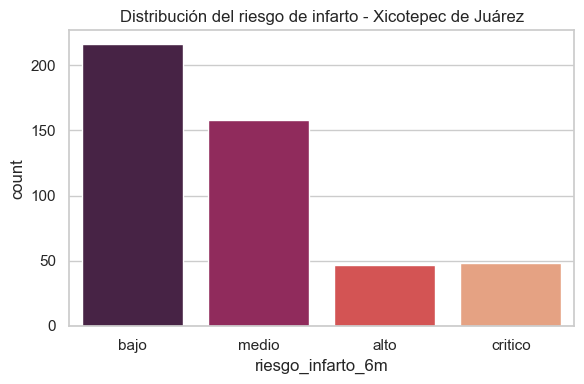

In [81]:
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# Crear la carpeta si no existe
RUTA_FIGURAS = Path("../outputs/figures")
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

orden = ['bajo','medio','alto','critico']

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_xico,
    x='riesgo_infarto_6m',
    order=orden,
    palette='rocket'
)

plt.title("Distribución del riesgo de infarto - Xicotepec de Juárez")
plt.tight_layout()

plt.savefig(
    RUTA_FIGURAS / "distribucion_riesgo_infarto_practica09.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

## 10. Seleccion de variables predictoras (evitando fuga de informacion)

Se excluyen `riesgo_cardiovascular` y `municipio` porque `riesgo_infarto_6m` se deriva
directamente de la primera, y `municipio` ya fue usado para el filtrado (no aporta
informacion nueva dentro de un dataset de un solo municipio).

In [82]:
features_num = ['edad','presion_sistolica','presion_diastolica','glucosa_mg_dl','colesterol_mg_dl','imc']
features_cat = ['sexo','tabaquismo','diabetes','actividad_fisica','antecedentes_familiares']

X = df_xico[features_num + features_cat].copy()
y = df_xico['riesgo_infarto_6m']

print("Variables predictoras:", list(X.columns))
assert 'riesgo_cardiovascular' not in X.columns
assert 'riesgo_infarto_6m' not in X.columns

Variables predictoras: ['edad', 'presion_sistolica', 'presion_diastolica', 'glucosa_mg_dl', 'colesterol_mg_dl', 'imc', 'sexo', 'tabaquismo', 'diabetes', 'actividad_fisica', 'antecedentes_familiares']


## 11. Valores nulos y atipicos

edad                       0
presion_sistolica          0
presion_diastolica         0
glucosa_mg_dl              0
colesterol_mg_dl           2
imc                        0
sexo                       0
tabaquismo                 0
diabetes                   0
actividad_fisica           0
antecedentes_familiares    0
dtype: int64
Nulos tras imputacion: 0


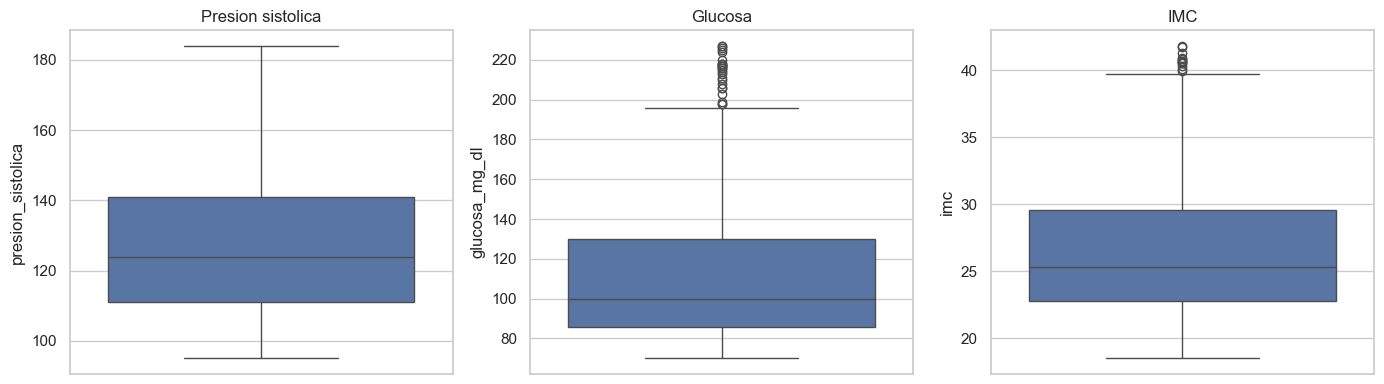

In [83]:
print(X.isnull().sum())

# Imputacion de nulos remanentes (colesterol) con la mediana, antes de modelar
for col in X.select_dtypes(include=[np.number]).columns:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].median())
print("Nulos tras imputacion:", X.isnull().sum().sum())

fig, axes = plt.subplots(1, 3, figsize=(14,4))
sns.boxplot(y=X['presion_sistolica'], ax=axes[0]); axes[0].set_title('Presion sistolica')
sns.boxplot(y=X['glucosa_mg_dl'], ax=axes[1]); axes[1].set_title('Glucosa')
sns.boxplot(y=X['imc'], ax=axes[2]); axes[2].set_title('IMC')
plt.tight_layout()
plt.savefig("../outputs/figures/atipicos_practica09.png", dpi=120)
plt.show()

## 12. Limpieza final del dataset de modelado

Ademas de imputar nulos, se acotan (capping) los valores atipicos detectados en las
variables numericas usando el criterio de rango intercuartilico (IQR), para evitar que
casos extremos simulados distorsionen el entrenamiento de los modelos.

In [84]:
outlier_report = {}
for col in features_num:
    q1, q3 = X[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_atipicos = ((X[col] < lim_inf) | (X[col] > lim_sup)).sum()
    outlier_report[col] = n_atipicos
    X[col] = X[col].clip(lower=lim_inf, upper=lim_sup)

print("Valores atipicos detectados y acotados (capping IQR) por columna:")
for col, n in outlier_report.items():
    print(f"  {col}: {n} valores acotados")

# Se reflejan los valores acotados tambien en df_xico, para mantener consistencia
# entre el dataset preparado que se exporta y las variables usadas para modelar
df_xico[features_num] = X[features_num]

Valores atipicos detectados y acotados (capping IQR) por columna:
  edad: 10 valores acotados
  presion_sistolica: 0 valores acotados
  presion_diastolica: 0 valores acotados
  glucosa_mg_dl: 26 valores acotados
  colesterol_mg_dl: 0 valores acotados
  imc: 13 valores acotados


## 13. Guardado del dataset filtrado y preparado

Se exporta el dataset de Xicotepec de Juarez ya filtrado, con la variable objetivo
definida y con nulos/atipicos tratados, antes de codificar y escalar para el modelado.

In [85]:
import os
os.makedirs("../data/processed", exist_ok=True)
df_xico.to_csv("../data/processed/dataset_xicotepec_preparado.csv", index=False)
print("Dataset filtrado y preparado guardado en ../data/processed/dataset_xicotepec_preparado.csv")
print("Filas:", df_xico.shape[0], "- Columnas:", df_xico.shape[1])

Dataset filtrado y preparado guardado en ../data/processed/dataset_xicotepec_preparado.csv
Filas: 469 - Columnas: 20


## 14. Codificacion de variables categoricas

In [86]:
X_encoded = pd.get_dummies(X, columns=features_cat, drop_first=True)
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)
print("Clases codificadas:", dict(zip(le_y.classes_, le_y.transform(le_y.classes_))))
X_encoded.head()

Clases codificadas: {'alto': np.int64(0), 'bajo': np.int64(1), 'critico': np.int64(2), 'medio': np.int64(3)}


,edad,presion_sistolica,presion_diastolica,glucosa_mg_dl,colesterol_mg_dl,imc,sexo_M,tabaquismo_si,diabetes_si,actividad_fisica_baja,actividad_fisica_moderada,antecedentes_familiares_si
0,31.0,96,63,92,132.0,19.3,False,False,False,False,True,True
1,57.0,148,104,165,292.0,36.2,True,False,False,False,False,False
2,28.0,118,64,87,155.0,21.1,True,False,False,False,True,False
3,31.0,107,78,95,138.0,23.1,True,False,False,False,False,False
4,42.0,100,63,71,144.0,23.5,True,True,False,True,False,False


## 15. Escalamiento de variables numericas

In [87]:
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[features_num] = scaler.fit_transform(X_encoded[features_num])
X_scaled.head()

,edad,presion_sistolica,presion_diastolica,glucosa_mg_dl,colesterol_mg_dl,imc,sexo_M,tabaquismo_si,diabetes_si,actividad_fisica_baja,actividad_fisica_moderada,antecedentes_familiares_si
0,-0.889063,-1.472864,-1.377555,-0.603815,-1.410572,-1.344472,False,False,False,False,True,True
1,0.678269,0.929986,1.753903,1.507164,2.268583,1.782044,True,False,False,False,False,False
2,-1.069909,-0.456273,-1.301178,-0.748403,-0.881693,-1.011470,True,False,False,False,True,False
3,-0.889063,-0.964568,-0.231900,-0.517062,-1.272603,-0.641468,True,False,False,False,False,False
4,-0.225961,-1.288029,-1.377555,-1.211083,-1.134635,-0.567468,True,True,False,True,False,False


## 16. Analisis exploratorio: edad, presion, glucosa y colesterol vs riesgo

C:\Users\dl799\AppData\Local\Temp\ipykernel_28468\2973500746.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_xico, x='riesgo_infarto_6m', y='edad', order=orden, ax=axes[0,0], palette='rocket')
C:\Users\dl799\AppData\Local\Temp\ipykernel_28468\2973500746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_xico, x='riesgo_infarto_6m', y='presion_sistolica', order=orden, ax=axes[0,1], palette='rocket')
C:\Users\dl799\AppData\Local\Temp\ipykernel_28468\2973500746.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_xic

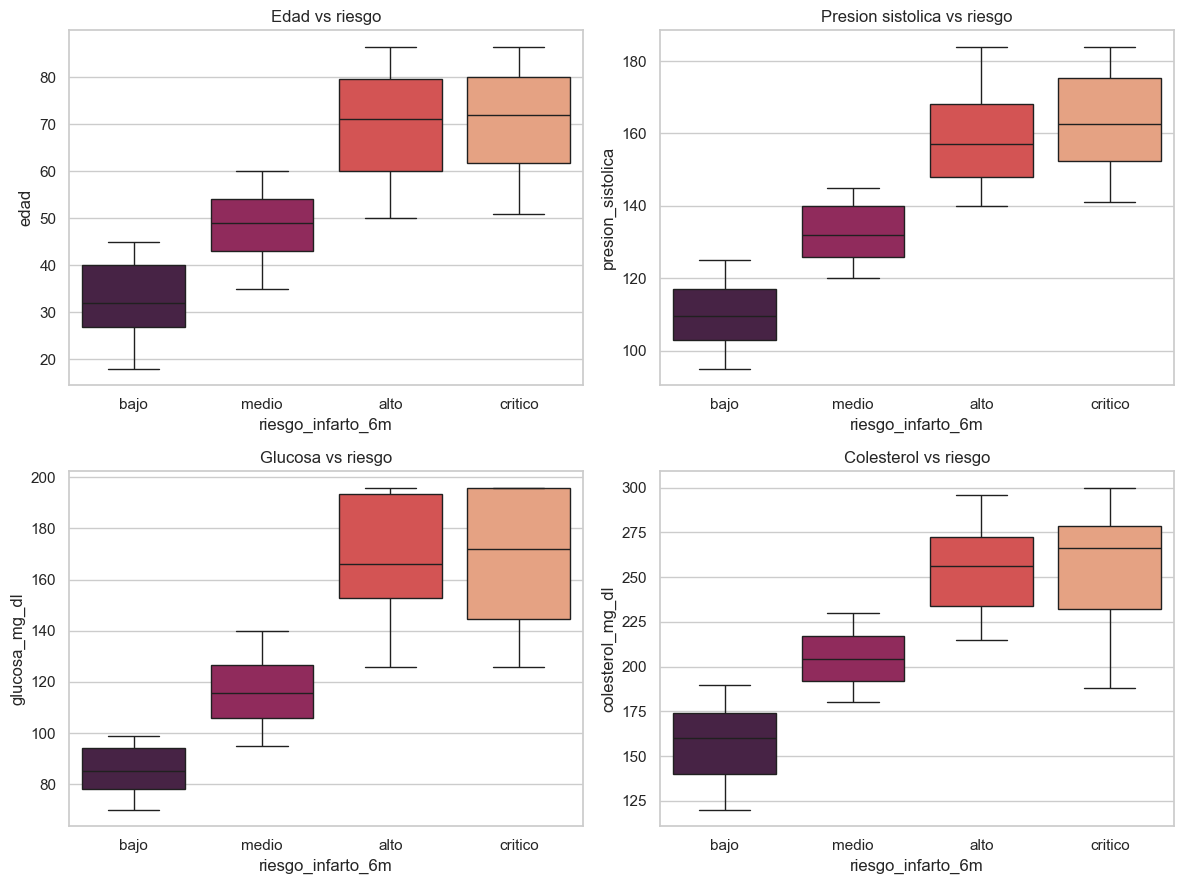

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.boxplot(data=df_xico, x='riesgo_infarto_6m', y='edad', order=orden, ax=axes[0,0], palette='rocket')
axes[0,0].set_title("Edad vs riesgo")

sns.boxplot(data=df_xico, x='riesgo_infarto_6m', y='presion_sistolica', order=orden, ax=axes[0,1], palette='rocket')
axes[0,1].set_title("Presion sistolica vs riesgo")

sns.boxplot(data=df_xico, x='riesgo_infarto_6m', y='glucosa_mg_dl', order=orden, ax=axes[1,0], palette='rocket')
axes[1,0].set_title("Glucosa vs riesgo")

sns.boxplot(data=df_xico, x='riesgo_infarto_6m', y='colesterol_mg_dl', order=orden, ax=axes[1,1], palette='rocket')
axes[1,1].set_title("Colesterol vs riesgo")

plt.tight_layout()
plt.savefig("../outputs/figures/clinicas_vs_riesgo_practica09.png", dpi=120)
plt.show()

## 17. Matriz de correlacion

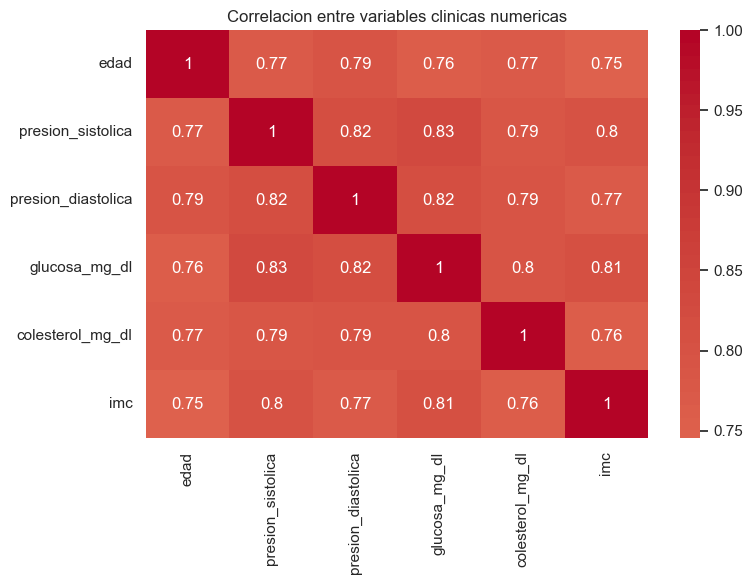

In [89]:
plt.figure(figsize=(8,6))
sns.heatmap(X_encoded[features_num].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlacion entre variables clinicas numericas")
plt.tight_layout()
plt.savefig("../outputs/figures/correlacion_practica09.png", dpi=120)
plt.show()

## 18. Division entrenamiento / prueba

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (375, 12) Test: (94, 12)


## 19. Modelo 1 - Regresion Logistica Multiclase

In [91]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
pred_lr = log_reg.predict(X_test)
print("Regresion Logistica - accuracy:", accuracy_score(y_test, pred_lr))

Regresion Logistica - accuracy: 0.9893617021276596


## 20. Modelo 2 - Random Forest

In [92]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Random Forest - accuracy:", accuracy_score(y_test, pred_rf))

Random Forest - accuracy: 0.9893617021276596


## 21. Modelo 3 - KNN

In [93]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
print("KNN - accuracy:", accuracy_score(y_test, pred_knn))

KNN - accuracy: 0.9574468085106383


## 22. Evaluacion comparativa

In [94]:
modelos_pred = {'Regresion Logistica': pred_lr, 'Random Forest': pred_rf, 'KNN': pred_knn}

filas = []
for nombre, pred in modelos_pred.items():
    filas.append({
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, pred, average='weighted', zero_division=0),
    })

resultados = pd.DataFrame(filas).sort_values('f1', ascending=False)
resultados

,modelo,accuracy,precision,recall,f1
0,Regresion Logistica,0.989362,0.990329,0.989362,0.989302
1,Random Forest,0.989362,0.990329,0.989362,0.989302
2,KNN,0.957447,0.970540,0.957447,0.955996


## 23. Matriz de confusion del mejor modelo

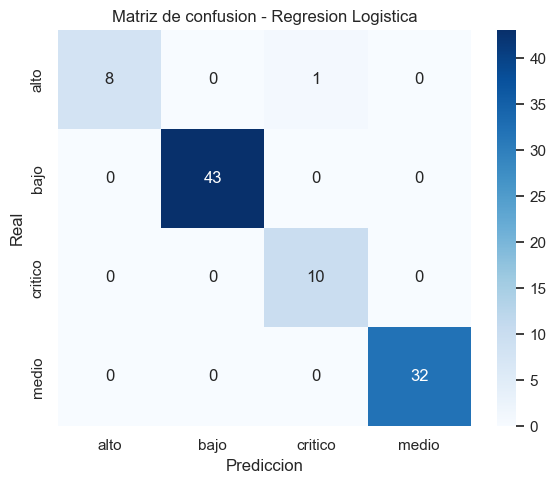

              precision    recall  f1-score   support

        alto       1.00      0.89      0.94         9
        bajo       1.00      1.00      1.00        43
     critico       0.91      1.00      0.95        10
       medio       1.00      1.00      1.00        32

    accuracy                           0.99        94
   macro avg       0.98      0.97      0.97        94
weighted avg       0.99      0.99      0.99        94



In [95]:
mejor_nombre = resultados.iloc[0]['modelo']
mejor_pred = modelos_pred[mejor_nombre]

cm = confusion_matrix(y_test, mejor_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.title(f"Matriz de confusion - {mejor_nombre}")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig("../outputs/figures/matriz_confusion_infarto_practica09.png", dpi=120)
plt.show()

print(classification_report(y_test, mejor_pred, target_names=le_y.classes_))

## 24. Interpretacion de errores de clasificacion

Se analiza, para cada clase de riesgo, cuantos casos fueron clasificados
correctamente y cual es la tasa de error, para identificar en que nivel de
riesgo se equivoca mas el modelo.

In [96]:
clases = le_y.classes_
errores_por_clase = {}
for i, clase in enumerate(clases):
    total_real = cm[i].sum()
    aciertos = cm[i, i]
    errores = total_real - aciertos
    tasa_error = errores / total_real if total_real > 0 else 0
    errores_por_clase[clase] = tasa_error
    print(f"Clase '{clase}': {aciertos}/{total_real} correctos, tasa de error = {tasa_error:.1%}")

clase_peor = max(errores_por_clase, key=errores_por_clase.get)
print(f"\nLa clase con mayor tasa de error es '{clase_peor}'.")
print("Esto suele ocurrir porque las clases limitrofes (por ejemplo 'alto' y 'critico', "
      "o 'bajo' y 'medio') comparten rangos clinicos similares, lo que dificulta que el "
      "modelo trace un limite de decision perfecto entre ellas, especialmente si hay pocos "
      "registros de esa clase en el conjunto de prueba.")

Clase 'alto': 8/9 correctos, tasa de error = 11.1%
Clase 'bajo': 43/43 correctos, tasa de error = 0.0%
Clase 'critico': 10/10 correctos, tasa de error = 0.0%
Clase 'medio': 32/32 correctos, tasa de error = 0.0%

La clase con mayor tasa de error es 'alto'.
Esto suele ocurrir porque las clases limitrofes (por ejemplo 'alto' y 'critico', o 'bajo' y 'medio') comparten rangos clinicos similares, lo que dificulta que el modelo trace un limite de decision perfecto entre ellas, especialmente si hay pocos registros de esa clase en el conjunto de prueba.


## 25. Importancia de variables (Random Forest)

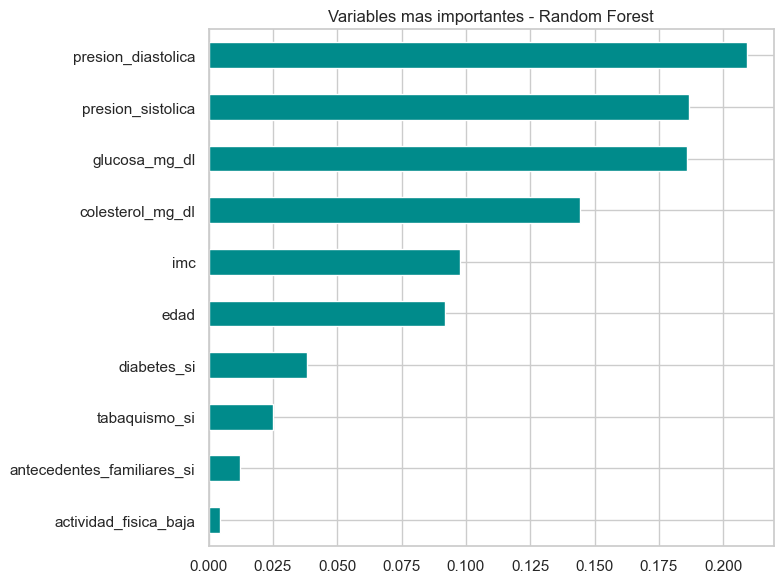

In [97]:
importancias = pd.Series(rf.feature_importances_, index=X_scaled.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importancias.head(10).plot(kind='barh', color='darkcyan')
plt.gca().invert_yaxis()
plt.title("Variables mas importantes - Random Forest")
plt.tight_layout()
plt.savefig("../outputs/figures/importancia_variables_practica09.png", dpi=120)
plt.show()

## 26. Interpretacion de las variables mas importantes

In [98]:
top3 = importancias.head(3)
print("Las 3 variables con mayor peso en la prediccion del Random Forest son:")
for i, (var, peso) in enumerate(top3.items(), start=1):
    print(f"  {i}. {var} (importancia relativa: {peso:.1%})")

print()
print("Esto es consistente con el criterio clinico esperado: la presion arterial y la "
      "glucosa son indicadores directos de riesgo cardiovascular agudo, por lo que es "
      "razonable que el modelo les asigne un peso alto al pronosticar el riesgo de infarto.")

Las 3 variables con mayor peso en la prediccion del Random Forest son:
  1. presion_diastolica (importancia relativa: 20.9%)
  2. presion_sistolica (importancia relativa: 18.7%)
  3. glucosa_mg_dl (importancia relativa: 18.6%)

Esto es consistente con el criterio clinico esperado: la presion arterial y la glucosa son indicadores directos de riesgo cardiovascular agudo, por lo que es razonable que el modelo les asigne un peso alto al pronosticar el riesgo de infarto.


## 27. Columna de prediccion final sobre todo el dataset de Xicotepec

In [99]:
mejor_modelo = {'Regresion Logistica': log_reg, 'Random Forest': rf, 'KNN': knn}[mejor_nombre]
df_xico['riesgo_predicho'] = le_y.inverse_transform(mejor_modelo.predict(X_scaled))
df_xico[['id_paciente','riesgo_infarto_6m','riesgo_predicho']].head(10)

,id_paciente,riesgo_infarto_6m,riesgo_predicho
0,GRP-000014,bajo,bajo
1,GRP-000026,alto,alto
2,GRP-000098,bajo,bajo
3,GRP-000129,bajo,bajo
4,GRP-000130,bajo,bajo
5,GRP-000158,bajo,bajo
6,GRP-000194,alto,alto
7,GRP-000209,bajo,bajo
8,GRP-000253,bajo,bajo
9,GRP-000263,bajo,bajo


## 28. Mapa de pacientes con riesgo alto/critico

In [100]:
from pathlib import Path
import folium

# Crear la carpeta de salida si no existe
RUTA_MAPAS = Path("../outputs/maps")
RUTA_MAPAS.mkdir(parents=True, exist_ok=True)

pacientes_riesgo = df_xico[
    df_xico["riesgo_predicho"].isin(["alto", "critico"])
]

print("Pacientes en riesgo alto/crítico:", len(pacientes_riesgo))

mapa_riesgo = folium.Map(
    location=[20.2789, -97.9539],
    zoom_start=12,
    tiles="CartoDB Positron"
)

colores = {
    "alto": "orange",
    "critico": "red"
}

for _, row in pacientes_riesgo.iterrows():
    folium.CircleMarker(
        location=[row["latitud"], row["longitud"]],
        radius=4,
        color=colores[row["riesgo_predicho"]],
        fill=True,
        fill_color=colores[row["riesgo_predicho"]],
        fill_opacity=0.7,
        popup=f"Paciente: {row['id_paciente']}<br>Riesgo: {row['riesgo_predicho']}"
    ).add_to(mapa_riesgo)

# Guardar el mapa
ruta_salida = RUTA_MAPAS / "mapa_riesgo_xicotepec.html"
mapa_riesgo.save(ruta_salida)

print("Mapa guardado en:", ruta_salida.resolve())

mapa_riesgo

Pacientes en riesgo alto/crítico: 95
Mapa guardado en: C:\Users\dl799\OneDrive\Documentos\Proyecto en Equipo\ECBD-9B-IDGS-PRACTICAS-PDP\outputs\maps\mapa_riesgo_xicotepec.html


## 29. Heatmap de riesgo cardiovascular

In [101]:
mapa_heat_riesgo = folium.Map(location=[20.2789, -97.9539], zoom_start=12, tiles="cartodbpositron")
puntos_riesgo = pacientes_riesgo[['latitud','longitud']].values.tolist()
HeatMap(puntos_riesgo, radius=15, blur=20).add_to(mapa_heat_riesgo)
mapa_heat_riesgo.save("../outputs/maps/heatmap_riesgo_xicotepec.html")
mapa_heat_riesgo

## 30. Identificacion de zonas prioritarias (clustering geografico)

Para pasar de una lectura visual del heatmap a un criterio mas objetivo, se agrupan
los pacientes con riesgo alto/critico en zonas geograficas usando K-Means sobre sus
coordenadas, y se calcula el centro de cada zona como propuesta concreta de ubicacion.

In [102]:
k_zonas = 3
coords_riesgo = pacientes_riesgo[['latitud', 'longitud']].values

kmeans_zonas = KMeans(n_clusters=k_zonas, random_state=42, n_init=10)
pacientes_riesgo = pacientes_riesgo.copy()
pacientes_riesgo['zona_prioritaria'] = kmeans_zonas.fit_predict(coords_riesgo)

resumen_zonas = (
    pacientes_riesgo.groupby('zona_prioritaria')
    .agg(n_pacientes=('id_paciente', 'count'),
         lat_centro=('latitud', 'mean'),
         lon_centro=('longitud', 'mean'))
    .sort_values('n_pacientes', ascending=False)
    .reset_index()
)
print("Resumen de zonas prioritarias (clustering K-Means):")
resumen_zonas

Resumen de zonas prioritarias (clustering K-Means):


c:\Users\dl799\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,zona_prioritaria,n_pacientes,lat_centro,lon_centro
0,0,39,20.319698,-97.979861
1,1,29,20.279681,-97.915849
2,2,27,20.231852,-97.959493


In [103]:
from pathlib import Path

# Crear carpetas de salida
RUTA_PROCESADOS = Path("../data/processed")
RUTA_MODELOS = Path("../outputs/models")

RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)
RUTA_MODELOS.mkdir(parents=True, exist_ok=True)

# Definir rutas completas
ruta_dataset = RUTA_PROCESADOS / "dataset_xicotepec_prediccion.csv"
ruta_resultados = RUTA_MODELOS / "comparacion_modelos_practica09.csv"

# Guardar archivos
df_xico.to_csv(ruta_dataset, index=False)
resultados.to_csv(ruta_resultados, index=False)

print("Archivos guardados correctamente:")
print("Dataset:", ruta_dataset.resolve())
print("Resultados:", ruta_resultados.resolve())

Archivos guardados correctamente:
Dataset: C:\Users\dl799\OneDrive\Documentos\Proyecto en Equipo\ECBD-9B-IDGS-PRACTICAS-PDP\data\processed\dataset_xicotepec_prediccion.csv
Resultados: C:\Users\dl799\OneDrive\Documentos\Proyecto en Equipo\ECBD-9B-IDGS-PRACTICAS-PDP\outputs\models\comparacion_modelos_practica09.csv


## 31. Propuesta de ubicacion de unidades de atencion urgente

Con base en el heatmap, las zonas con mayor densidad de puntos naranja/rojo alrededor de la
cabecera de Xicotepec de Juarez son las candidatas prioritarias para una unidad de atencion
cardiovascular urgente, ya que concentran simultaneamente mayor volumen de pacientes y mayor
proporcion de riesgo alto/critico. La propuesta considera:

- **Concentracion de pacientes en riesgo:** priorizar el area de mayor densidad en el heatmap.
- **Accesibilidad geografica:** una ubicacion cercana al centro urbano favorece tiempos de
  traslado mas cortos para la mayoria de los casos detectados.
- **Distribucion del riesgo:** si existieran sub-concentraciones alejadas del centro, se
  recomendaria evaluar una segunda unidad movil o punto de referencia.

Estas conclusiones son orientativas y estan basadas enteramente en datos simulados.

Los centros de zona calculados en la seccion anterior (`resumen_zonas`) sirven como coordenadas concretas de referencia para esta propuesta, priorizando la zona con mayor numero de pacientes en riesgo.

## 32. Relacion de los resultados con la toma de decisiones

El analisis supervisado permite pasar de un registro clinico individual a una vista
poblacional del riesgo cardiovascular en Xicotepec de Juarez. Al combinar la prediccion
de riesgo con la ubicacion geografica de cada paciente, este tipo de modelo puede apoyar:

- **Planeacion hospitalaria:** estimar cuantos pacientes en riesgo alto/critico existen en
  una zona y anticipar la demanda de atencion cardiovascular urgente.
- **Atencion preventiva:** priorizar campanas de deteccion (presion, glucosa, colesterol) en
  las zonas identificadas por el clustering, en lugar de aplicar el mismo esfuerzo a todo el
  municipio por igual.
- **Asignacion de recursos:** justificar, con datos y no solo con percepcion, en que colonias
  o localidades convendria reforzar unidades moviles o puntos de atencion urgente.

Es importante recalcar que estas conclusiones son un ejercicio didactico: en un escenario
real, decisiones de este tipo requieren validacion con personal de salud y datos clinicos
verificados, no unicamente un modelo entrenado con datos simulados.

## 33. Limitaciones del analisis

- El dataset es completamente simulado; los valores clinicos, la geolocalizacion y el riesgo
  de infarto se generaron con reglas probabilisticas simples, no con historiales clinicos reales.
- La variable `riesgo_infarto_6m` es una derivacion didactica de `riesgo_cardiovascular` y no
  un resultado de seguimiento clinico real.
- Los modelos entrenados **no deben usarse para ningun tipo de decision medica real**; su
  proposito es exclusivamente academico, para practicar clasificacion supervisada multiclase
  y su relacion con analisis geoespacial.

## 34. Guardado de resultados finales

In [104]:
df_xico.to_csv("../data/processed/dataset_xicotepec_prediccion.csv", index=False)
resultados.to_csv("../outputs/models/comparacion_modelos_practica09.csv", index=False)
print("Resultados guardados en data/processed/ y outputs/models/")

Resultados guardados en data/processed/ y outputs/models/
